# Rule-based Penguin Classification

In [1]:
# read the data file

def read_data(filename):
    with open(filename) as f:
        lines = f.readlines()

    header = lines[0].strip()
    column_names = header.split(',')

    # instances = []
    # for line in lines[1:]:
        # items = line.strip().split(',')
        # instances.append(items)

    instances = [line.strip().split(',')
                 for line in lines[1:]]

    return column_names, instances

In [2]:
filename = '/Users/liubingyi/Documents/learn/data/palmer-penguins-train.txt'

column_names, instances = read_data(filename)

print('column names:', column_names)

print('total number of instances:', len(instances))

for instance in instances[:5]:
    print(instance)

column names: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']
total number of instances: 172
['Adelie', 'Torgersen', '39.1', '18.7', '181.0', '3750.0', 'male', '2007']
['Adelie', 'Torgersen', '40.3', '18.0', '195.0', '3250.0', 'female', '2007']
['Adelie', 'Torgersen', '36.7', '19.3', '193.0', '3450.0', 'female', '2007']
['Adelie', 'Torgersen', '38.9', '17.8', '181.0', '3625.0', 'female', '2007']
['Adelie', 'Torgersen', '34.1', '18.1', '193.0', '3475.0', '', '2007']


In [4]:
# read the variables: class label and features
#这里是类型转换，将字符串换成浮点数，并且处理空白值
def string2float(item):
    # if item != '':
        # result = float(item)
    # else:
        # result = None
    result = float(item) if item != '' else None
    return result

#开始读标签
def read_species(filename):
    with open(filename) as f:
        lines = f.readlines()
    values = [line.strip().split(',')[0]#这里就是第一列被取出来
              for line in lines[1:]]
    return values

#开始读数据
def read_bill_lengths(filename):
    with open(filename) as f:
        lines = f.readlines()
    values = [string2float(line.strip().split(',')[2])#这里就是第三列被取出来
              for line in lines[1:]]
    return values

In [5]:
filename = '/Users/liubingyi/Documents/learn/data/palmer-penguins-train.txt'

species = read_species(filename)
bill_lengths = read_bill_lengths(filename)
#::20表示
print('     species:', species[::20])
print('bill lengths:', bill_lengths[::20])

     species: ['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Gentoo', 'Chinstrap', 'Chinstrap']
bill lengths: [39.1, 36.5, 34.6, 36.2, 43.3, 44.9, 47.5, 52.7, 50.9]


In [6]:
# read the variables: class label and features

def string2float(item):
    return float(item) if item != '' else None

#这里读的是字符串与浮点数
def read_strings(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [line.strip().split(',')[col]#col应该是列的参数column，后面可以传递参数进来
              for line in lines[1:]]
    return values

def read_floats(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [string2float(line.strip().split(',')[col])
              for line in lines[1:]]
    return values

In [7]:
filename = '/Users/liubingyi/Documents/learn/data/palmer-penguins-train.txt'

species = read_strings(filename, col=0)
islands = read_strings(filename, col=1)
bill_lengths = read_floats(filename, col=2)
bill_depths = read_floats(filename, col=3)
flipper_lengths =  read_floats(filename, col=4)

print('        species:', species[::20])
print('        islands:', islands[::20])
print('   bill lengths:', bill_lengths[::20])
print('    bill depths:', bill_depths[::20])
print('flipper lengths:', flipper_lengths[::20])

        species: ['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Gentoo', 'Chinstrap', 'Chinstrap']
        islands: ['Torgersen', 'Dream', 'Torgersen', 'Torgersen', 'Biscoe', 'Biscoe', 'Biscoe', 'Dream', 'Dream']
   bill lengths: [39.1, 36.5, 34.6, 36.2, 43.3, 44.9, 47.5, 52.7, 50.9]
    bill depths: [18.7, 18.0, 17.2, 17.2, 13.4, 13.3, 14.0, 19.8, 17.9]
flipper lengths: [181.0, 182.0, 189.0, 187.0, 209.0, 213.0, 212.0, 197.0, 196.0]


In [8]:
# get data per category
#这里的enumerate采用的是（索引，值），所以这里就是在target的对应
def get_items_of_species(items, species, target_species_name):
    items = [items[idx] for idx, species_name in enumerate(species)
             if species_name == target_species_name]
    return items

In [9]:
print('species:', set(species))

islands_a = get_items_of_species(islands, species, 'Adelie')
islands_c = get_items_of_species(islands, species, 'Chinstrap')
islands_g = get_items_of_species(islands, species, 'Gentoo')

print('islands of    Adelie:', islands_a[::10])#这里就是表示Adelie存在的岛屿叫做a
print('islands of Chinstrap:', islands_c[::10])
print('islands of    Gentoo:', islands_g[::10])

species: {'Gentoo', 'Chinstrap', 'Adelie'}
islands of    Adelie: ['Torgersen', 'Biscoe', 'Dream', 'Biscoe', 'Torgersen', 'Biscoe', 'Torgersen', 'Dream']
islands of Chinstrap: ['Dream', 'Dream', 'Dream', 'Dream']
islands of    Gentoo: ['Biscoe', 'Biscoe', 'Biscoe', 'Biscoe', 'Biscoe', 'Biscoe', 'Biscoe']


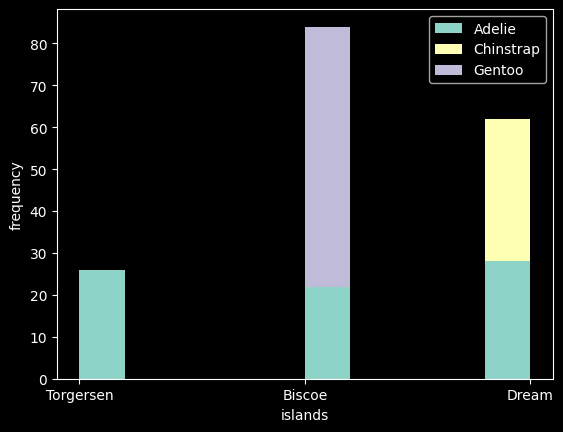

In [10]:
# plot histogram这里的histogram就是直方图

import matplotlib.pyplot as plt

h = plt.hist([islands_a, islands_c, islands_g], stacked=True)
plt.xlabel('islands')
plt.ylabel('frequency')
plt.legend(['Adelie', 'Chinstrap', 'Gentoo'])

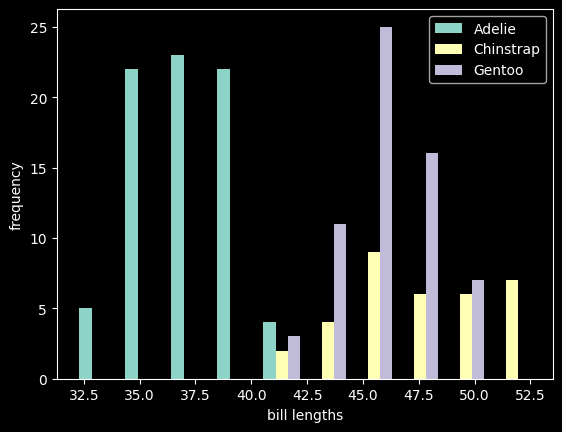

In [11]:
# plot histogram

bill_lengths_a = get_items_of_species(bill_lengths, species, 'Adelie')
bill_lengths_c = get_items_of_species(bill_lengths, species, 'Chinstrap')
bill_lengths_g = get_items_of_species(bill_lengths, species, 'Gentoo')

#同时绘制三组数据的直方图，系统会自动分配不同颜色

h = plt.hist([bill_lengths_a, bill_lengths_c, bill_lengths_g], stacked=False)
plt.xlabel('bill lengths')
plt.ylabel('frequency')
plt.legend(['Adelie', 'Chinstrap', 'Gentoo'])

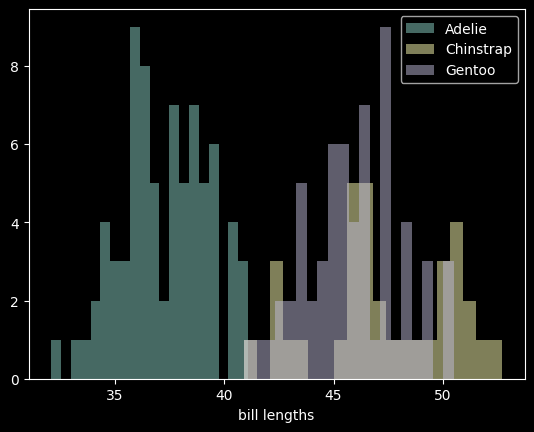

In [12]:
# plot histogram

def plot_overlapping_histgrams(data, label_names, xlabel=''):
    for idx in range(len(data)): # loop for each category
        plt.hist(data[idx], alpha=0.5, bins=20, label=label_names[idx])#这里的alpha就是透明度，bins就是区间的数量
    plt.xlabel(xlabel)
    plt.legend(loc='upper right')# 自动收集所有hist中的label，放在右上角

data = [bill_lengths_a, bill_lengths_c, bill_lengths_g]
plot_overlapping_histgrams(data=data,
                           label_names=['Adelie', 'Chinstrap', 'Gentoo'],
                           xlabel='bill lengths')

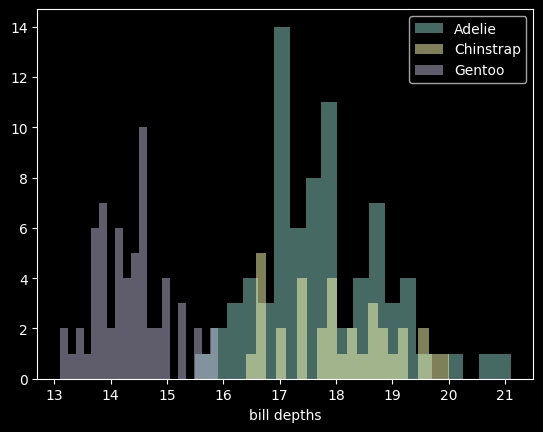

In [13]:
# plot histogram

bill_depths_a = get_items_of_species(bill_depths, species, 'Adelie')#这里就是获取所有的Adelie鸟类的bill——depth
bill_depths_c = get_items_of_species(bill_depths, species, 'Chinstrap')
bill_depths_g = get_items_of_species(bill_depths, species, 'Gentoo')

data = [bill_depths_a, bill_depths_c, bill_depths_g]
plot_overlapping_histgrams(data, ['Adelie', 'Chinstrap', 'Gentoo'], 'bill depths')

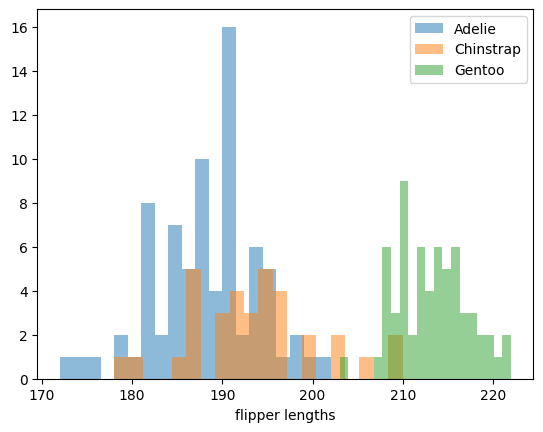

In [18]:
# plot histogram

flipper_lengths_a = get_items_of_species(flipper_lengths, species, 'Adelie')
flipper_lengths_c = get_items_of_species(flipper_lengths, species, 'Chinstrap')
flipper_lengths_g = get_items_of_species(flipper_lengths, species, 'Gentoo')

data = [flipper_lengths_a, flipper_lengths_c, flipper_lengths_g]
plot_overlapping_histgrams(data, ['Adelie', 'Chinstrap', 'Gentoo'], 'flipper lengths')

In [14]:
# make prediction
#这是一个非常简单的根据图示得到的简易规律
def classify(island, bill_length, bill_depth, flipper_length):
    if island == 'Torgerson' or bill_length < 41.0:
        predicted_label = 'Adelie'
    elif bill_depth < 15.4 and flipper_length > 210.0:
        predicted_label = 'Gentoo'
    else:
        predicted_label = 'Chinstrap'
    return predicted_label

# ground truth: Adelie
predicted_label = classify(island='Torgerson',
                           bill_length=39.5,
                           bill_depth=17.4,
                           flipper_length=186.0)
print('the predicted class is:', predicted_label)

# ground truth: Chinstrap
predicted_label = classify(island='Dream',
                           bill_length=50.2,
                           bill_depth=18.7,
                           flipper_length=198.0)
print('the predicted class is:', predicted_label)

the predicted class is: Adelie
the predicted class is: Chinstrap


In [15]:
# make prediction and evaluation

class Penguin:
    def __init__(self, line):
        items = line.strip().split(',')
        self.species = items[0]
        self.island = items[1]
        self.bill_length = string2float(items[2])
        self.bill_depth = string2float(items[3])
        self.flipper_length = string2float(items[4])

    def classify(self):
        if None in (self.island, self.bill_length, self.bill_depth, self.flipper_length):
            return None
        if self.island == 'Torgerson' or self.bill_length < 41.0:
            predicted_label = 'Adelie'
        elif self.bill_depth < 15.4 and self.flipper_length > 210.0:
            predicted_label = 'Gentoo'
        else:
            predicted_label = 'Chinstrap'
        return predicted_label

In [18]:
# training set

filename = '/Users/liubingyi/Documents/learn/data/palmer-penguins-train.txt'
with open(filename) as f:
    lines = f.readlines()[1:]

num_total = len(lines)
num_valid = 0# 有效的预测数--因为有些特征不明确的可能是none
num_correct = 0# 正确的预测数
for idx, line in enumerate(lines):
    penguin = Penguin(line)
    ground_truth_label = penguin.species# 真实标签（如 'Adelie'）
    predicted_label = penguin.classify()# 这里是预测标签
    if predicted_label is not None:
        num_valid += 1
        is_correct = ground_truth_label == predicted_label
        if is_correct:
            num_correct += 1
    else:
        is_correct = None
    # print('[{:03d}/{}] ground truth {:>9s}, predicted as {:>9s} - {}'.format(idx + 1, num_total, ground_truth_label, str(predicted_label), str(is_correct)))

accuracy = num_correct / num_valid
print('training set accuracy:', accuracy)

training set accuracy: 0.8313953488372093


In [17]:
# test set

file_name = '/Users/liubingyi/Documents/learn/data/palmer-penguins-test.txt'
with open(file_name) as f:
    lines = f.readlines()[1:]

num_total = len(lines)
num_valid = 0
num_correct = 0
for idx, line in enumerate(lines):
    penguin = Penguin(line)
    ground_truth_label = penguin.species
    predicted_label = penguin.classify()
    if predicted_label is not None:
        num_valid += 1
        is_correct = ground_truth_label == predicted_label
        if is_correct:
            num_correct += 1
    else:
        is_correct = None
    # print('[{:03d}/{}] ground truth {:>9s}, predicted as {:>9s} - {}'.format(idx + 1, num_total, ground_truth_label, str(predicted_label), str(is_correct)))

accuracy = num_correct / num_valid
print('    test set accuracy:', accuracy)

    test set accuracy: 0.5764705882352941
